# 1. Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
from sklearn.metrics import mean_absolute_percentage_error, r2_score
from sklearn.metrics import mean_squared_error

import seaborn as sns
# PyTorch Lightning and Forecasting
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger

# PyTorch Forecasting
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss, MAE, RMSE, SMAPE

# Set random seeds for reproducibility
pl.seed_everything(42)

c:\Users\User\anaconda3\envs\forecast_env\Lib\site-packages\pytorch_forecasting\models\base\_base_model.py:28: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm
Seed set to 42


42

In [2]:
# Load data
file_path = r"C:\Users\User\Documents\Semester 07\EE4750 - Data Analytics in Power Systems\WindPowerForecastingData TASK.xlsx\WindPowerForecastingData TASK1.xlsx"
data = pd.read_excel(file_path, engine='openpyxl')

print("Data loaded successfully!")
print("Initial data shape:", data.shape)
print("\nFirst few rows:")
print(tabulate(data.head(), headers='keys', tablefmt='psql'))

Data loaded successfully!
Initial data shape: (16776, 6)

First few rows:
+----+---------------+-------------+---------+-----------+---------+-----------+
|    | TIMESTAMP     |   TARGETVAR |     U10 |       V10 |    U100 |      V100 |
|----+---------------+-------------+---------+-----------+---------+-----------|
|  0 | 20120101 1:00 |   0         | 2.1246  | -2.68197  | 2.86428 | -3.66608  |
|  1 | 20120101 2:00 |   0.0548791 | 2.52169 | -1.79696  | 3.34486 | -2.46476  |
|  2 | 20120101 3:00 |   0.110234  | 2.67221 | -0.822516 | 3.50845 | -1.21409  |
|  3 | 20120101 4:00 |   0.165116  | 2.4575  | -0.143642 | 3.21523 | -0.355546 |
|  4 | 20120101 5:00 |   0.15694   | 2.2459  |  0.389576 | 2.95768 |  0.332701 |
+----+---------------+-------------+---------+-----------+---------+-----------+


In [3]:
data.describe()

,TARGETVAR,U10,V10,U100,V100
count,16765.000000,16776.000000,16776.000000,16776.000000,16776.000000
mean,0.303185,0.940139,-0.249900,1.577437,-0.552801
std,0.289702,2.555295,2.921128,4.262811,5.030008
min,0.000000,-7.494252,-9.993858,-10.910809,-15.294866
25%,0.063340,-1.057063,-2.339844,-1.734356,-4.612835
50%,0.206841,0.793579,-0.041186,1.497473,0.132922
75%,0.479184,2.590033,1.931172,4.686485,3.492502
max,1.000000,11.117029,9.508798,16.988418,14.314416


In [4]:
data['TIMESTAMP'] = pd.to_datetime(data['TIMESTAMP'])
print(tabulate(data.head(), headers='keys', tablefmt='psql'))

+----+---------------------+-------------+---------+-----------+---------+-----------+
|    | TIMESTAMP           |   TARGETVAR |     U10 |       V10 |    U100 |      V100 |
|----+---------------------+-------------+---------+-----------+---------+-----------|
|  0 | 2012-01-01 01:00:00 |   0         | 2.1246  | -2.68197  | 2.86428 | -3.66608  |
|  1 | 2012-01-01 02:00:00 |   0.0548791 | 2.52169 | -1.79696  | 3.34486 | -2.46476  |
|  2 | 2012-01-01 03:00:00 |   0.110234  | 2.67221 | -0.822516 | 3.50845 | -1.21409  |
|  3 | 2012-01-01 04:00:00 |   0.165116  | 2.4575  | -0.143642 | 3.21523 | -0.355546 |
|  4 | 2012-01-01 05:00:00 |   0.15694   | 2.2459  |  0.389576 | 2.95768 |  0.332701 |
+----+---------------------+-------------+---------+-----------+---------+-----------+


In [5]:
# Handle missing values
data.isnull().sum()
data = data = data.fillna(method='ffill').fillna(method='bfill')

C:\Users\User\AppData\Local\Temp\ipykernel_8624\3053543252.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data = data.fillna(method='ffill').fillna(method='bfill')


In [6]:

from sklearn.preprocessing import MinMaxScaler

cols = ['U10','V10','U100','V100']
scaler = MinMaxScaler()
data[cols] = scaler.fit_transform(data[cols])
print(tabulate(data.head(), headers='keys', tablefmt='psql'))

+----+---------------------+-------------+----------+----------+----------+----------+
|    | TIMESTAMP           |   TARGETVAR |      U10 |      V10 |     U100 |     V100 |
|----+---------------------+-------------+----------+----------+----------+----------|
|  0 | 2012-01-01 01:00:00 |   0         | 0.516829 | 0.374918 | 0.493744 | 0.392741 |
|  1 | 2012-01-01 02:00:00 |   0.0548791 | 0.538165 | 0.420297 | 0.51097  | 0.433314 |
|  2 | 2012-01-01 03:00:00 |   0.110234  | 0.546253 | 0.470261 | 0.516834 | 0.475553 |
|  3 | 2012-01-01 04:00:00 |   0.165116  | 0.534716 | 0.50507  | 0.506324 | 0.504549 |
|  4 | 2012-01-01 05:00:00 |   0.15694   | 0.523347 | 0.532411 | 0.497092 | 0.527793 |
+----+---------------------+-------------+----------+----------+----------+----------+


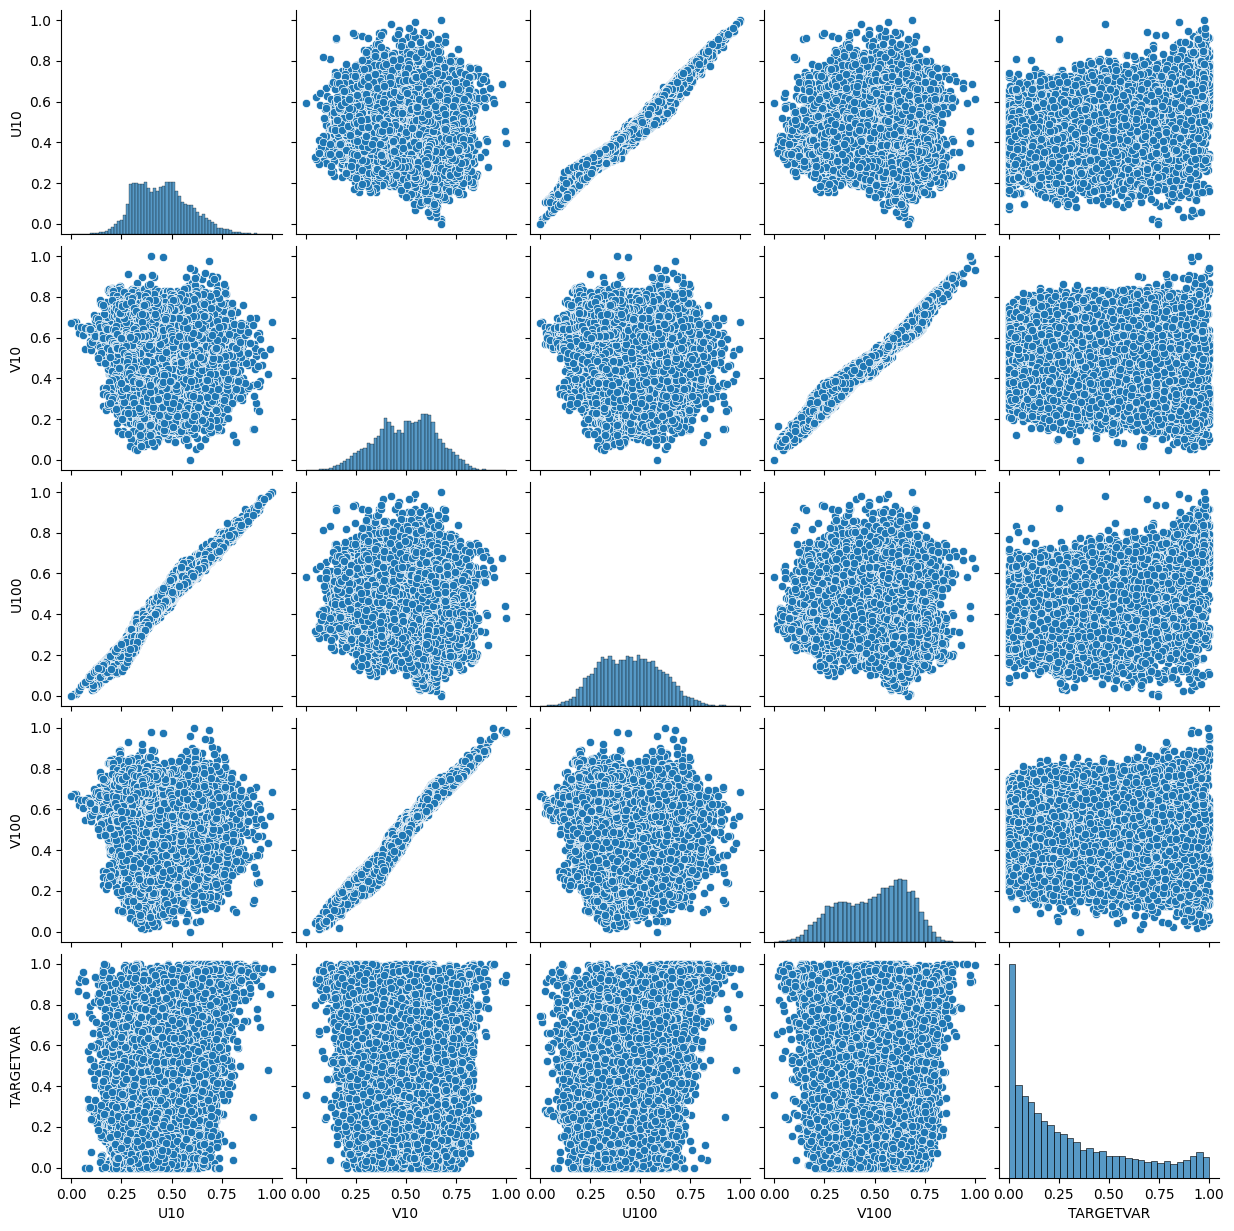

In [7]:
sns.pairplot(data[cols + ['TARGETVAR']])
plt.show()

Text(0.5, 1.0, 'Correlation Matrix')

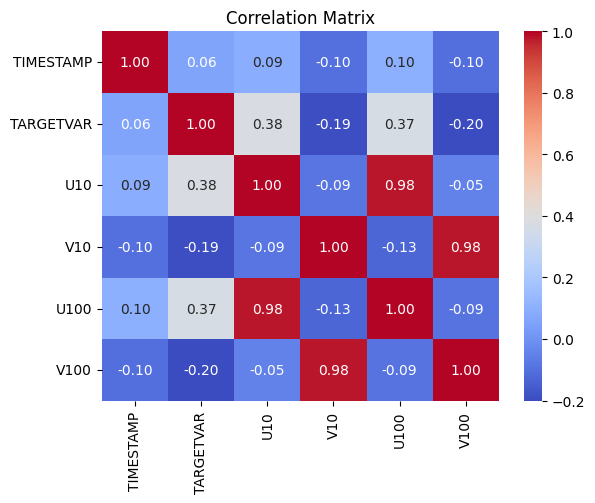

In [8]:
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")

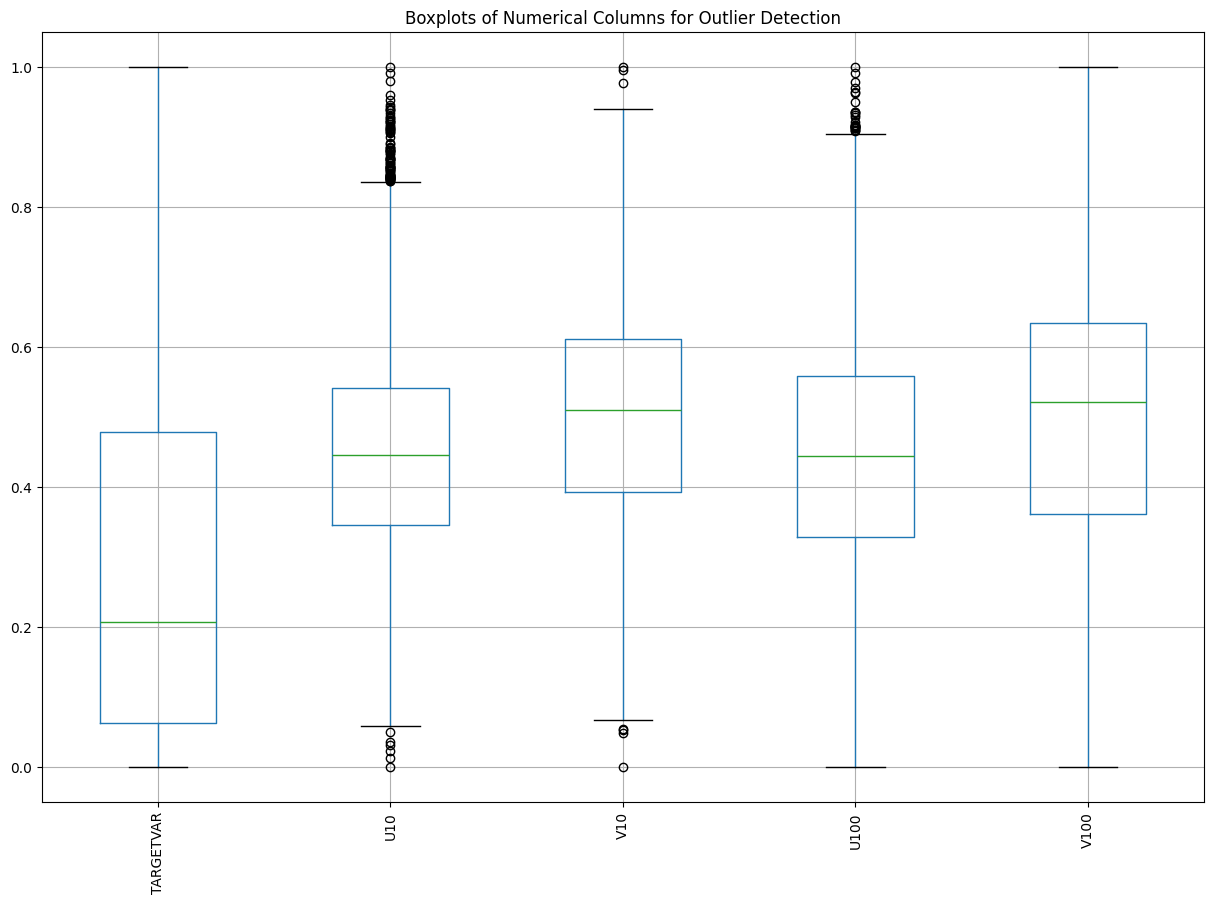

In [9]:
# Plotting boxplots to visualize outliers in numerical columns
cols = ['TARGETVAR', 'U10', 'V10', 'U100', 'V100']

plt.figure(figsize=(15, 10))
data[cols].boxplot()
plt.xticks(rotation=90)
plt.title('Boxplots of Numerical Columns for Outlier Detection')
plt.show()


In [10]:
# Calculating Q1, Q3, and IQR for each numerical column
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

# Defining the boundaries for detecting outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtering out rows that contain outliers beyond the IQR boundaries
outliers_filtered_data = data[~((data < lower_bound) | (data > upper_bound)).any(axis=1)]

# Displaying the shape of the data before and after outlier removal
data_shape_before = data.shape
data_shape_after = outliers_filtered_data.shape

data_shape_before, data_shape_after

((16776, 6), (16680, 6))

In [11]:
# Define the split index (80% train, 20% test)
train_size = int(len(outliers_filtered_data) * 0.8)

# Split into train and test sets
train_df = outliers_filtered_data[:train_size].copy()
test_df = outliers_filtered_data[train_size:].copy()

print(f"Training set: {train_df.shape}")
print(f"Test set: {test_df.shape}")

Training set: (13344, 6)
Test set: (3336, 6)


In [12]:
train_df["TIMESTAMP"] = pd.to_datetime(train_df["TIMESTAMP"])
train_df["time_idx"] = (train_df["TIMESTAMP"] - train_df["TIMESTAMP"].min()).dt.total_seconds() // 3600  # hourly steps
train_df["time_idx"] = train_df["time_idx"].astype(int)
train_df["group"] = 0  # single series

train_df = train_df.sort_values(["group","time_idx"]).reset_index(drop=True)

training = TimeSeriesDataSet(
    train_df,
    time_idx="time_idx",
    target="TARGETVAR",
    group_ids=["group"],
    max_encoder_length=168,
    max_prediction_length=24,
    time_varying_known_reals=["U10","V10","U100","V100"],
    time_varying_unknown_reals=["TARGETVAR"],
    allow_missing_timesteps=True
)


In [13]:
# Find the maximum time_idx in train_df
max_time_idx_train = train_df["time_idx"].max()

# Adjust time_idx in test_df to be sequential from max_time_idx_train + 1
test_df["time_idx"] = range(max_time_idx_train + 1, max_time_idx_train + 1 + len(test_df))

# Print to confirm changes
print(f"Adjusted time_idx in test_df: {test_df['time_idx'].min()} to {test_df['time_idx'].max()}")

Adjusted time_idx in test_df: 13399 to 16734


In [14]:
# If you used a constant group in training
test_df = test_df.copy()
test_df["group"] = 0   # or whatever grouping key you used in train_df


In [15]:
# Recreate the validation dataset from the corrected test_df
validation = TimeSeriesDataSet.from_dataset(
    training,
    test_df,
    min_prediction_idx=max_time_idx_train + 1  # Use the new start of time_idx in test_df
)

# Define a suitable batch size
batch_size = 64  # Adjust this value as needed based on your data and memory

# Create dataloaders again
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=11)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=11)

In [16]:
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.03,
    hidden_size=16,
    attention_head_size=1,
    dropout=0.1,
    hidden_continuous_size=8,
    output_size=7,  # Number of quantiles by default
    loss=QuantileLoss(),
    log_interval=10,
    reduce_on_plateau_patience=4,
)

c:\Users\User\anaconda3\envs\forecast_env\Lib\site-packages\lightning\pytorch\utilities\parsing.py:210: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\User\anaconda3\envs\forecast_env\Lib\site-packages\lightning\pytorch\utilities\parsing.py:210: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [17]:
from pytorch_lightning import Trainer, LightningModule 
import torch

class TFTLightningModule(LightningModule):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return self.model(x)  # pass the full batch dict, not unpacked x, y

    def training_step(self, batch, batch_idx):
       
        x, y = batch
        
        out = self.model(x)
        y_pred = out[0]  
        loss = self.model.loss(y_pred, y)
        
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True, batch_size=x['encoder_target'].shape[0])
        return loss

    def validation_step(self, batch, batch_idx):
        # Doğrulama adımını gerçekleştir
        x, y = batch
        out = self.model(x)
        y_pred = out[0]  
        loss = self.model.loss(y_pred, y)
        
        self.log("val_loss", loss, prog_bar=True, batch_size=x['encoder_target'].shape[0])
        return loss

    def configure_optimizers(self):
        
        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.model.hparams.learning_rate)
        return optimizer
        
    def test_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self.model(x)
        loss = self.loss(y_hat, y)
        self.log("test_loss", loss)
        return {"test_loss": loss}


In [18]:
from pytorch_lightning.loggers import TensorBoardLogger
logger = TensorBoardLogger("lightning_logs", name="tft")
# Create the LightningModule
tft_module = TFTLightningModule(tft)
# Trainer instance
trainer = Trainer(
    max_epochs=10,
    accelerator="auto",
    logger=logger,
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[EarlyStopping(monitor="val_loss", patience=3, verbose=True)],
    num_sanity_val_steps=0,
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [19]:
# Model training
trainer.fit(
    tft_module,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader
)


  | Name  | Type                      | Params | Mode 
------------------------------------------------------------
0 | model | TemporalFusionTransformer | 19.6 K | train
------------------------------------------------------------
19.6 K    Trainable params
0         Non-trainable params
19.6 K    Total params
0.078     Total estimated model params size (MB)
273       Modules in train mode
0         Modules in eval mode
c:\Users\User\anaconda3\envs\forecast_env\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:428: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.
c:\Users\User\anaconda3\envs\forecast_env\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:428: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.


Epoch 0: 100%|██████████| 204/204 [01:21<00:00,  2.52it/s, v_num=13, train_loss_step=0.0721, val_loss=0.0958, train_loss_epoch=0.0847]

Metric val_loss improved. New best score: 0.096


Epoch 1: 100%|██████████| 204/204 [03:38<00:00,  0.93it/s, v_num=13, train_loss_step=0.0805, val_loss=0.0895, train_loss_epoch=0.0758]

Metric val_loss improved by 0.006 >= min_delta = 0.0. New best score: 0.090


...

Epoch 4: 100%|██████████| 204/204 [03:40<00:00,  0.92it/s, v_num=13, train_loss_step=0.0659, val_loss=0.0785, train_loss_epoch=0.0693]

Metric val_loss improved by 0.004 >= min_delta = 0.0. New best score: 0.079


Epoch 7: 100%|██████████| 204/204 [03:44<00:00,  0.91it/s, v_num=13, train_loss_step=0.0741, val_loss=0.0817, train_loss_epoch=0.064] 

Monitored metric val_loss did not improve in the last 3 records. Best score: 0.079. Signaling Trainer to stop.


Epoch 7: 100%|██████████| 204/204 [03:44<00:00,  0.91it/s, v_num=13, train_loss_step=0.0741, val_loss=0.0817, train_loss_epoch=0.064]


In [20]:
torch.save(tft.state_dict(), "model_results/tft_final_model.pth")

In [21]:
#Load model
tft.load_state_dict(torch.load("model_results/tft_final_model.pth"))


<All keys matched successfully>

In [22]:
test_dataset = TimeSeriesDataSet.from_dataset(
    training,  # Use the settings from training dataset
    test_df,     
    predict=True
)

# Create test DataLoader
test_dataloader = test_dataset.to_dataloader(train=False, batch_size=64)


c:\Users\User\anaconda3\envs\forecast_env\Lib\site-packages\pytorch_forecasting\data\timeseries\_timeseries.py:1712: UserWarning: If predicting, no randomization should be possible - setting stop_randomization=True
  warnings.warn(


In [23]:
# Get raw predictions and inputs from the model on the test set
raw_predictions = tft.predict(val_dataloader, mode="raw", return_x=True)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\User\anaconda3\envs\forecast_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:428: Consider setting `persistent_workers=True` in 'predict_dataloader' to speed up the dataloader worker initialization.


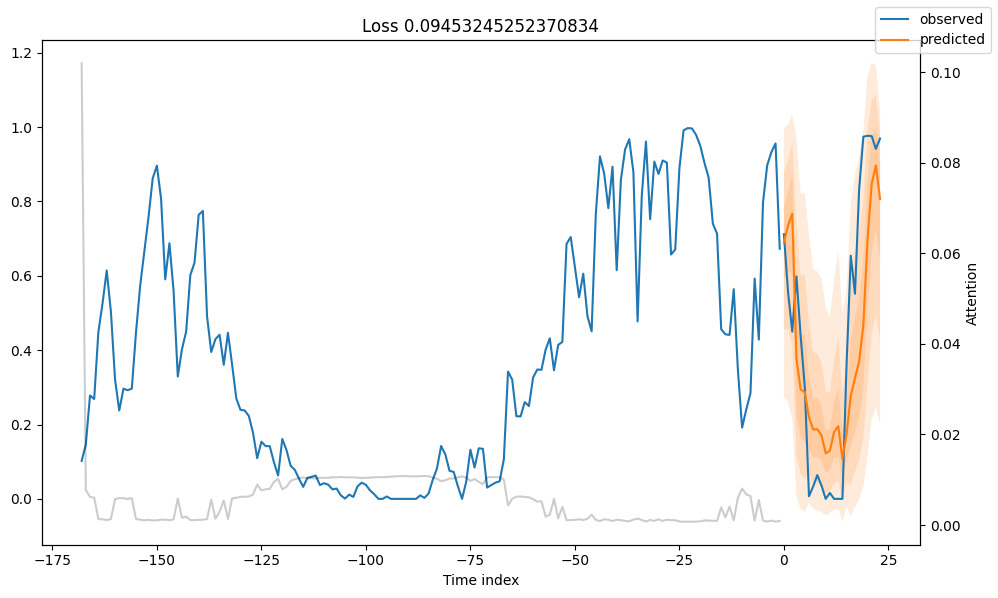

In [24]:
# Extract 'output' and 'x' from the 'raw_predictions'
out = raw_predictions.output
x = raw_predictions.x

# Visualize predictions for the single available sample in the test set
fig, ax = plt.subplots(figsize=(10, 6))
tft.plot_prediction(x=x, out=out, idx=0, add_loss_to_title=True, ax=ax)
plt.show()
fig.savefig("plots/predictions.png", dpi=300, bbox_inches="tight")

In [25]:
predictions = tft.predict(val_dataloader, mode="prediction")
predictions_df = pd.DataFrame(predictions.numpy())
actuals = []
for batch in iter(val_dataloader):
    # Assuming the target values are the second item in the batch
    targets = batch[1]  # Extract target tensor
    # If targets is a tuple, take the first tensor
    if isinstance(targets, tuple):
        targets = targets[0]
    actuals.append(targets)

# Concatenate all target tensors and convert to numpy
actuals = torch.cat(actuals).numpy()

# Create a DataFrame for actual values for better visualization
actuals_df = pd.DataFrame(actuals)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [26]:
# Calculate error 
mae = (predictions_df - actuals_df).abs().mean().mean()
mse = mean_squared_error(actuals_df, predictions_df)
rmse = np.sqrt(mse)
r2 = r2_score(actuals_df.values.flatten(), predictions_df.values.flatten())

print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

R² Score: 0.5571
Mean Absolute Error (MAE): 0.1516
Mean Squared Error (MSE): 0.0449
Root Mean Squared Error (RMSE): 0.2120


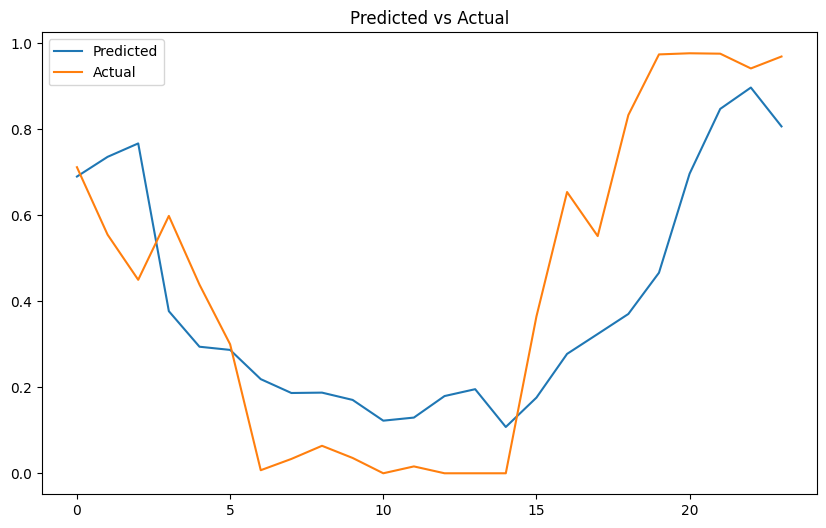

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(predictions_df.iloc[0], label="Predicted")
plt.plot(actuals_df.iloc[0], label="Actual")
plt.title("Predicted vs Actual")
plt.legend()
plt.show()
fig.savefig("plots/prevsactual.png", dpi=300, bbox_inches="tight")

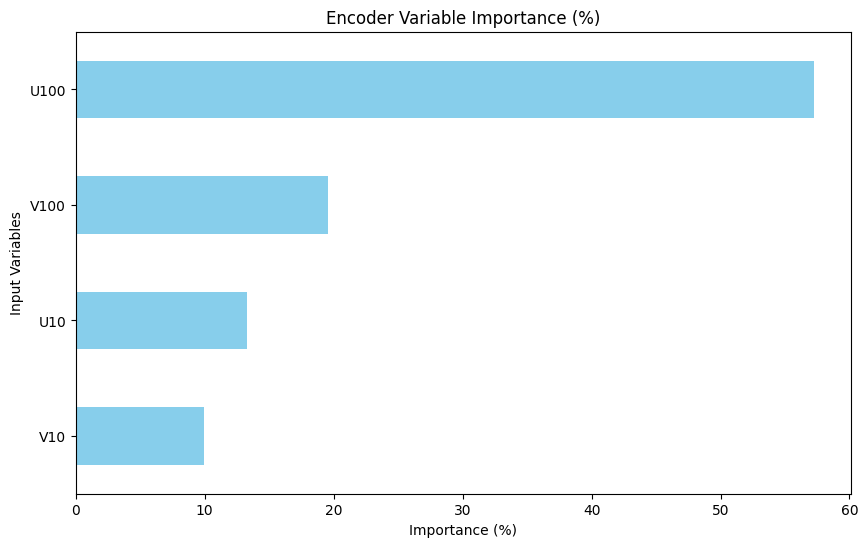

In [28]:
# Step 1: Sum importance over batch, time, and singleton dim
importance = out.encoder_variables.sum(dim=(0,1,2)).detach().cpu().numpy()  # shape = (num_input_variables,)

# Step 2: Convert to pandas Series with variable names
importance_series = pd.Series(importance, index=test_dataset.reals)

# Step 3: Remove target variable (replace 'targetvar' with your actual target name)
importance_series = importance_series.drop('TARGETVAR')

# Step 4: Normalize to percentage
importance_series = 100 * importance_series / importance_series.sum()

# Step 5: Sort for horizontal bar plot
importance_series = importance_series.sort_values(ascending=True)

# Step 6: Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
importance_series.plot(kind="barh", color="skyblue")
plt.title("Encoder Variable Importance (%)")
plt.xlabel("Importance (%)")
plt.ylabel("Input Variables")
plt.show()
fig.savefig("plots/encoder_variable_importance.png", dpi=300, bbox_inches="tight")


In [33]:
import json


def calculate_metrics(mae, mse, rmse, r2):
    metrics = {
        "mae": float(mae),
        "mse": float(mse),
        "rmse": float(rmse),
        "r2": float(r2)
    }
    return metrics

def create_prediction_json(predictions_df, actuals_df, feature_importance, metrics, output_filename):
    # Extract the same data points used in the plot
    pred_points = predictions_df.iloc[0].tolist()
    act_points = actuals_df.iloc[0].tolist()
    
    # Create JSON structure
    json_data = {
        "predictions": [float(p) for p in pred_points],
        "actuals": [float(a) for a in act_points],
        "feature_importance": feature_importance,
        "metrics": metrics
    }
    with open(output_filename, "w") as f:
        json.dump(json_data, f, indent=4)
        
    return json_data


# Compute metrics first
metrics = calculate_metrics(mae, mse, rmse, r2)

# Convert feature importances to dictionary
feature_importance = importance_series.to_dict()

# Create JSON for plotted data (same points as plot)
create_prediction_json(
    predictions_df=predictions_df,
    actuals_df=actuals_df,
    feature_importance=feature_importance,
    metrics=metrics,
    output_filename="predictions_plot_data.json"
)




{'predictions': [0.6899523735046387,
  0.7357529997825623,
  0.7669937014579773,
  0.37692609429359436,
  0.2942606508731842,
  0.2868696451187134,
  0.21890410780906677,
  0.18667230010032654,
  0.1875278651714325,
  0.17056694626808167,
  0.12232732772827148,
  0.1295154094696045,
  0.17955313622951508,
  0.1955268383026123,
  0.10764575004577637,
  0.17592453956604004,
  0.27757835388183594,
  0.32385876774787903,
  0.37039369344711304,
  0.4662932753562927,
  0.6966075897216797,
  0.8472678661346436,
  0.8969017267227173,
  0.8065758943557739],
 'actuals': [0.7116811871528625,
  0.5548350811004639,
  0.4498637318611145,
  0.5984399914741516,
  0.4386805593967438,
  0.2999717891216278,
  0.007139247842133045,
  0.03335271403193474,
  0.06389789283275604,
  0.035608142614364624,
  0.0,
  0.015964195132255554,
  0.0,
  0.0,
  0.0,
  0.3646244406700134,
  0.6539798974990845,
  0.5515459179878235,
  0.832910418510437,
  0.9739686250686646,
  0.976599931716919,
  0.9756601452827454,
  0.